In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('../data/raw/bank_marketing.csv')

# Drop 'unknown' contact type — keep only cellular vs telephone
df = df[df['contact'].isin(['cellular', 'telephone'])].copy()
df['treated'] = (df['contact'] == 'cellular').astype(int)
df['converted'] = (df['deposit'] == 'yes').astype(int)

print(df.shape)
df['contact'].value_counts()

(8816, 19)


contact
cellular     8042
telephone     774
Name: count, dtype: int64

In [2]:
naive_rates = df.groupby('contact')['converted'].mean()
print("Naive conversion rates by contact type:")
print(naive_rates)

# Naive t-test — this is what someone would do WITHOUT accounting for confounding
from statsmodels.stats.proportion import proportions_ztest
cellular = df[df['treated']==1]['converted']
telephone = df[df['treated']==0]['converted']
count = np.array([cellular.sum(), telephone.sum()])
nobs = np.array([len(cellular), len(telephone)])
z_stat, p_val = proportions_ztest(count, nobs)
print(f"\nNaive z-test p-value: {p_val:.6f}")
print(f"Naive observed difference: {(cellular.mean()-telephone.mean())*100:.2f}pp")

Naive conversion rates by contact type:
contact
cellular     0.543273
telephone    0.503876
Name: converted, dtype: float64

Naive z-test p-value: 0.035699
Naive observed difference: 3.94pp


In [3]:
# Unlike the simulated A/B test, this WASN'T randomized — check for confounding
print("Age by contact type:")
print(df.groupby('contact')['age'].mean())

print("\nBalance (account balance) by contact type:")
print(df.groupby('contact')['balance'].mean())

print("\nPrevious campaign contacts by contact type:")
print(df.groupby('contact')['previous'].mean())

print("\nHousing loan rate by contact type:")
print(df.groupby('contact')['housing'].apply(lambda x: (x=='yes').mean()))

Age by contact type:
contact
cellular     40.601094
telephone    50.436693
Name: age, dtype: float64

Balance (account balance) by contact type:
contact
cellular     1544.239368
telephone    2241.622739
Name: balance, dtype: float64

Previous campaign contacts by contact type:
contact
cellular     1.043148
telephone    1.054264
Name: previous, dtype: float64

Housing loan rate by contact type:
contact
cellular     0.416687
telephone    0.311370
Name: housing, dtype: float64


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Encode confounders we want to control for
df['housing_bin'] = (df['housing'] == 'yes').astype(int)
df['loan_bin'] = (df['loan'] == 'yes').astype(int)
df['default_bin'] = (df['default'] == 'yes').astype(int)

confounders = ['age', 'balance', 'housing_bin', 'loan_bin', 'default_bin', 'previous']
X_ps = df[confounders]
y_ps = df['treated']

scaler = StandardScaler()
X_ps_scaled = scaler.fit_transform(X_ps)

ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(X_ps_scaled, y_ps)

df['propensity_score'] = ps_model.predict_proba(X_ps_scaled)[:, 1]

print(df.groupby('contact')['propensity_score'].describe())

            count      mean       std       min       25%       50%       75%  \
contact                                                                         
cellular   8042.0  0.917781  0.058523  0.467251  0.899215  0.939752  0.955090   
telephone   774.0  0.854901  0.116320  0.219667  0.823116  0.891468  0.941646   

                max  
contact              
cellular   0.986030  
telephone  0.975068  


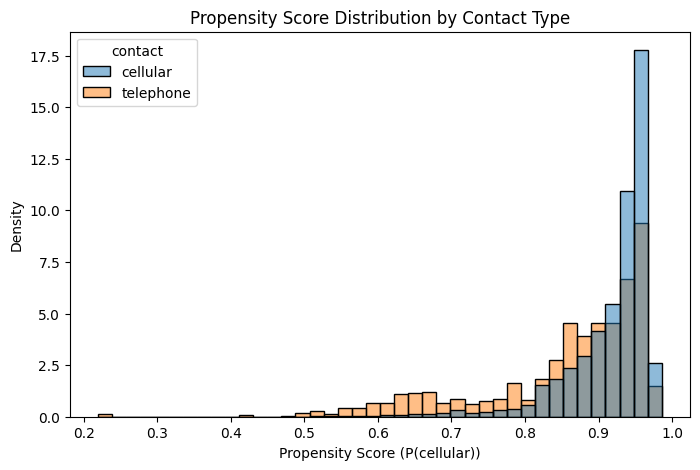

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='propensity_score', hue='contact', bins=40, alpha=0.5, stat='density', common_norm=False)
plt.title('Propensity Score Distribution by Contact Type')
plt.xlabel('Propensity Score (P(cellular))')
plt.savefig('../reports/figures/propensity_overlap.png', bbox_inches='tight')
plt.show()

In [6]:
from sklearn.neighbors import NearestNeighbors

treated = df[df['treated']==1].reset_index(drop=True)
control = df[df['treated']==0].reset_index(drop=True)

nn = NearestNeighbors(n_neighbors=1)
nn.fit(treated[['propensity_score']])
distances, indices = nn.kneighbors(control[['propensity_score']])

matched_treated = treated.iloc[indices.flatten()].reset_index(drop=True)
matched_control = control.reset_index(drop=True)

caliper = 0.1 * df['propensity_score'].std()
good_matches = distances.flatten() <= caliper
matched_treated = matched_treated[good_matches]
matched_control = matched_control[good_matches]

print(f"Matched pairs: {len(matched_control)} (out of {len(control)} telephone customers)")
print(f"Dropped {(~good_matches).sum()} due to caliper (poor match quality)")

Matched pairs: 767 (out of 774 telephone customers)
Dropped 7 due to caliper (poor match quality)


In [7]:
print("=== BEFORE matching ===")
print(f"Age diff: {treated['age'].mean() - control['age'].mean():.2f}")
print(f"Balance diff: {treated['balance'].mean() - control['balance'].mean():.2f}")

print("\n=== AFTER matching ===")
print(f"Age diff: {matched_treated['age'].mean() - matched_control['age'].mean():.2f}")
print(f"Balance diff: {matched_treated['balance'].mean() - matched_control['balance'].mean():.2f}")

=== BEFORE matching ===
Age diff: -9.84
Balance diff: -697.38

=== AFTER matching ===
Age diff: -0.02
Balance diff: 70.78


In [8]:
matched_effect = matched_treated['converted'].mean() - matched_control['converted'].mean()
print(f"Naive (unmatched) difference: {(treated['converted'].mean() - control['converted'].mean())*100:.2f}pp")
print(f"Matched (causal) estimate: {matched_effect*100:.2f}pp")

count = np.array([matched_treated['converted'].sum(), matched_control['converted'].sum()])
nobs = np.array([len(matched_treated), len(matched_control)])
z_stat, p_val = proportions_ztest(count, nobs)
print(f"Matched z-test p-value: {p_val:.4f}")

Naive (unmatched) difference: 3.94pp
Matched (causal) estimate: 9.39pp
Matched z-test p-value: 0.0002
